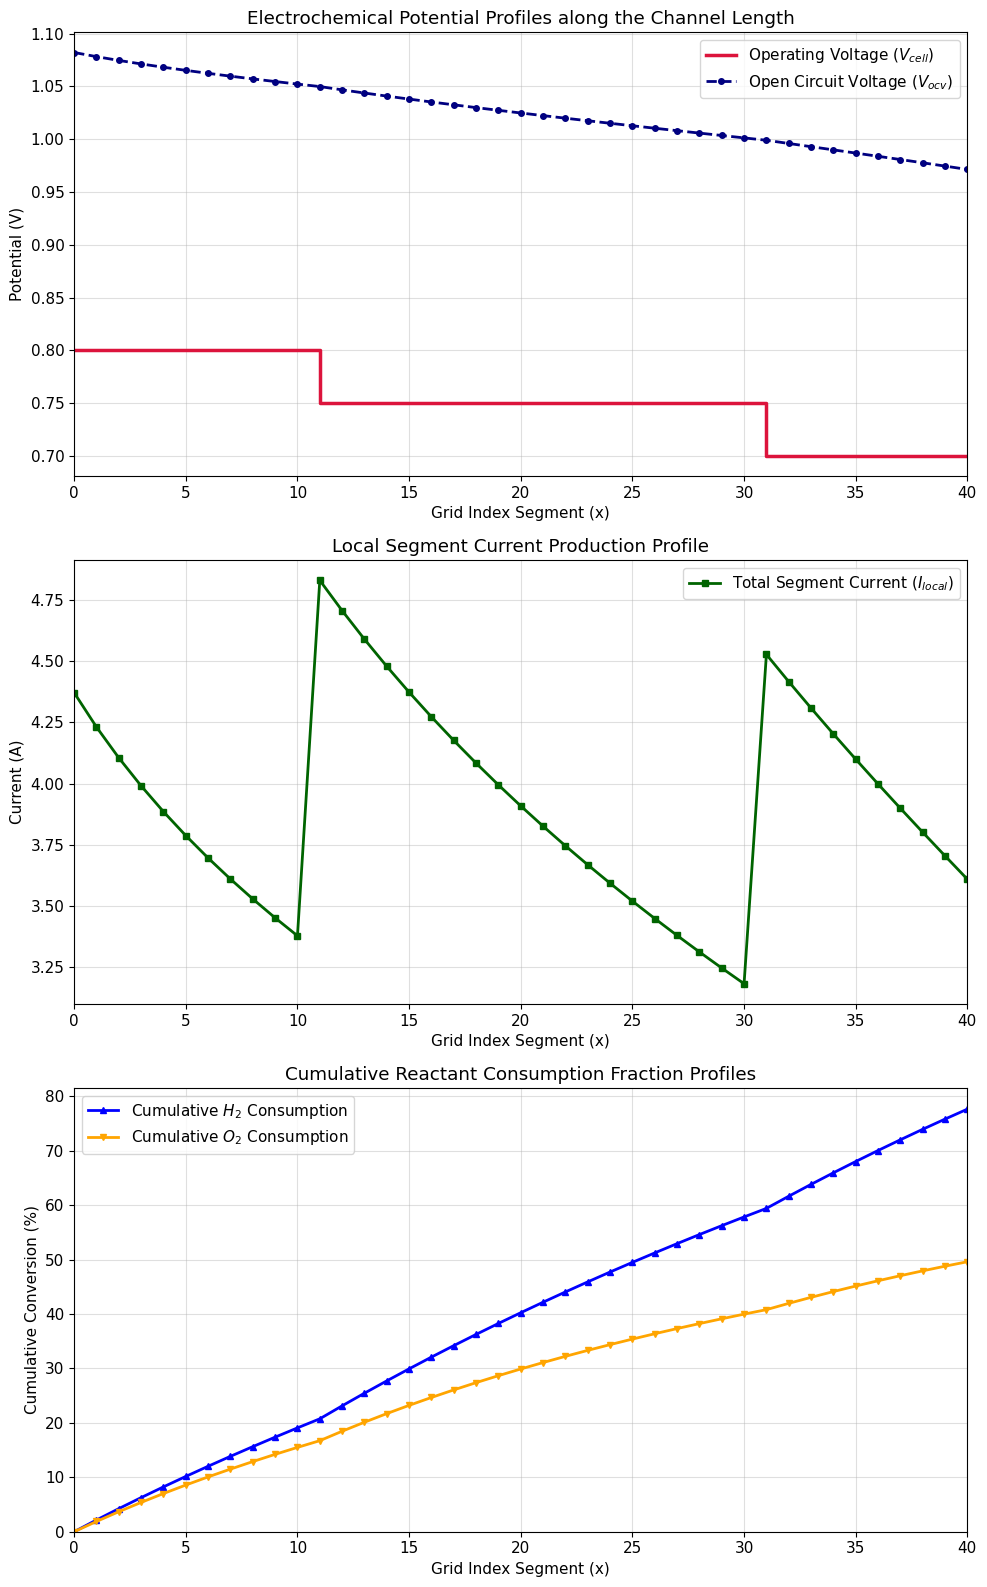

In [71]:
import numpy as np
import cantera as ct
from scipy.optimize import root
import matplotlib.pyplot as plt

# =============================================================================
# 1. FIXED PHYSICAL PARAMETERS & SYSTEM SPECIFICATIONS
# =============================================================================
P_kpa = 101.325        # kPa
P_pa = P_kpa * 1000.0  # Pa
F = 96485.0            # A-s/mol
R = 8.314              # J/mol-K
n = 2
Nseg = 40              # Total channel slices (Matching iter = 40)

i0_an = 0.3            # A/cm^2
i0_anCO = 0.05         # A/cm^2
i0_ca = 0.075          # A/cm^2
A_act = 160.0           # cm^2
A_seg = A_act / Nseg   # 2.0 cm^2 per slice

# CRISP VOLTAGE PROFILE
V_cell_target = np.zeros(Nseg + 1)
for i in range(Nseg + 1):
    if i <= 10:        # 0 to 10 -> Exactly 0.80V
        V_cell_target[i] = 0.80
    elif i <= 20:      # 11 to 20 -> Exactly 0.70V
        V_cell_target[i] = 0.75
    elif i <= 30:      # 21 to 30 -> Exactly 0.60V
        V_cell_target[i] = 0.75
    else:              # 31 to 40 -> Exactly 0.50V
        V_cell_target[i] = 0.7

# INITIAL INLET FLOW RATES MULTIPLIED BY 5 (mol/s)
n_dot_CO_0  = 0.2e-4 * 15.0
n_dot_CO2_0 = 0.1e-4 * 15.0
n_dot_H2_0  = 0.6e-4 * 15.0
n_dot_H2O_0 = 0.1e-4 * 15.0
n_dot_O2_0  = 0.4e-4 * 15.0

# Linear temperature channel profile
T_cell_mesh = np.linspace(837.0, 837.0 + (40 * 1.15), Nseg + 1)

# Initialize Cantera Base Database
gas = ct.Solution('gri30.yaml')

def get_cantera_gibbs(species, Temp):
    gas.TPX = Temp, P_pa, {species: 1.0}
    h = gas.enthalpy_mole  # J/mol
    s = gas.entropy_mole   # J/mol-K
    return (h - Temp * s) / 1000.0  # Converted to kJ/mol

# =============================================================================
# 2. SPACIAL CHANNEL INTEGRATION LOOP WITH ARRAYS
# =============================================================================
n_dot_H2 = np.zeros(Nseg + 2)
n_dot_CO = np.zeros(Nseg + 2)
n_dot_H2O = np.zeros(Nseg + 2)
n_dot_CO2 = np.zeros(Nseg + 2)
n_dot_fuel_tot = np.zeros(Nseg + 2)
pO2_channel = np.zeros(Nseg + 2)

# Boundary condition assignment at Node 0
n_dot_H2[0]  = n_dot_H2_0
n_dot_CO[0]  = n_dot_CO_0
n_dot_H2O[0] = n_dot_H2O_0
n_dot_CO2[0] = n_dot_CO2_0
n_dot_fuel_tot[0] = n_dot_H2_0 + n_dot_H2O_0 + n_dot_CO_0 + n_dot_CO2_0
pO2_channel[0] = 21.0  # kPa

# Result logs for graphing profile vectors
x_grid = np.arange(Nseg + 1)
V_ocv_out = []
I_total_out = []

for i in range(Nseg + 1):
    T_i = T_cell_mesh[i]

    pH2_i  = P_kpa * n_dot_H2[i] / n_dot_fuel_tot[i]
    pCO_i  = P_kpa * n_dot_CO[i] / n_dot_fuel_tot[i]
    pH2O_i = P_kpa * n_dot_H2O[i] / n_dot_fuel_tot[i]
    pCO2_i = P_kpa * n_dot_CO2[i] / n_dot_fuel_tot[i]
    pO2_i  = pO2_channel[i]

    g_H2  = get_cantera_gibbs('H2', T_i)
    g_O2  = get_cantera_gibbs('O2', T_i)
    g_H2O = get_cantera_gibbs('H2O', T_i)
    g_CO  = get_cantera_gibbs('CO', T_i)
    g_CO2 = get_cantera_gibbs('CO2', T_i)

    del_G0  = -1.0 * (g_H2O - g_H2 - 0.5 * g_O2)
    del_GC0 = -1.0 * (g_CO2 - g_CO - 0.5 * g_O2)

    V1 = del_G0 / (n * F)
    V2 = (R * T_i) / (n * F) * np.log(((pH2_i / P_kpa) * ((pO2_i / P_kpa)**0.5)) / (pH2O_i / P_kpa))
    Vn = V1 + V2

    VC1 = del_GC0 / (n * F)
    VC2 = (R * T_i) / (n * F) * np.log(((pCO_i / P_kpa) * ((pO2_i / P_kpa)**0.5)) / (pCO2_i / P_kpa))
    VCn = VC1 + VC2

    V_ocv = (Vn + VCn) / 2.0
    V_ocv_out.append(V_ocv)

    def butler_volmer_residuals(guesses):
        j_step, j2_step, V_act_an, V_act_ca = guesses
        res1 = j_step - i0_an * (np.exp((0.5 * n * F * V_act_an) / (R * T_i)) - np.exp(-(0.5 * n * F * V_act_an) / (R * T_i)))
        res2 = (j_step + j2_step) - i0_ca * (np.exp((0.5 * n * F * V_act_ca) / (R * T_i)) - np.exp(-(0.5 * n * F * V_act_ca) / (R * T_i)))
        res3 = j2_step - i0_anCO * (np.exp((0.5 * n * F * V_act_an) / (R * T_i)) - np.exp(-(0.5 * n * F * V_act_an) / (R * T_i)))
        V_loss_calc = V_act_an + V_act_ca
        res4 = V_cell_target[i] - (V_ocv - V_loss_calc)
        return [res1, res2, res3, res4]

    sol = root(butler_volmer_residuals, [0.3, 0.05, 0.05, 0.05], method='lm')
    j_val, j2_val, van, vca = sol.x

    # Calculate total current output for this segment (Amps)
    I_local = (j_val + j2_val) * A_seg
    I_total_out.append(I_local)

    # Step mass flow vectors forward
    n_dot_H2[i+1]  = n_dot_H2[i]  - (j_val * A_seg / (n * F))
    n_dot_CO[i+1]  = n_dot_CO[i]  - (j2_val * A_seg / (n * F))
    n_dot_H2O[i+1] = n_dot_H2O[i] + (j_val * A_seg / (n * F))
    n_dot_CO2[i+1] = n_dot_CO2[i] + (j2_val * A_seg / (n * F))
    n_dot_fuel_tot[i+1] = n_dot_H2[i+1] + n_dot_H2O[i+1] + n_dot_CO2[i+1] + n_dot_CO[i+1]
    pO2_channel[i+1] = pO2_channel[i] - ((0.5 * (j_val + j2_val) * A_seg / (n * F)) / n_dot_O2_0) * pO2_channel[i]

# Compute true cumulative fraction of mass utilization down the grid array
cum_consumption_H2 = (n_dot_H2_0 - n_dot_H2[:-1]) / n_dot_H2_0
# Oxygen flow rate conversion from partial pressure tracking for true mass balance
n_dot_O2_tracked = n_dot_O2_0 * (pO2_channel[:-1] / 21.0)
cum_consumption_O2 = (n_dot_O2_0 - n_dot_O2_tracked) / n_dot_O2_0

# =============================================================================
# 3. PLOTTING SUITE INTERFACES
# =============================================================================
plt.figure(figsize=(10, 16))
plt.rcParams.update({'font.size': 11, 'axes.grid': True, 'grid.alpha': 0.4})

# Plot I: V_cell and V_ocv vs x
plt.subplot(3, 1, 1)
plt.step(x_grid, V_cell_target, where='post', color='crimson', linewidth=2.5, label=r'Operating Voltage ($V_{cell}$)')
plt.plot(x_grid, V_ocv_out, color='navy', linestyle='--', linewidth=2, marker='o', markersize=4, label=r'Open Circuit Voltage ($V_{ocv}$)')
plt.title('Electrochemical Potential Profiles along the Channel Length')
plt.xlabel('Grid Index Segment (x)')
plt.ylabel('Potential (V)')
plt.xlim(0, Nseg)
plt.legend(loc='best')

# Plot II: Local Segment Current vs x
plt.subplot(3, 1, 2)
plt.plot(x_grid, I_total_out, color='darkgreen', linewidth=2, marker='s', markersize=4, label='Total Segment Current ($I_{local}$)')
plt.title('Local Segment Current Production Profile')
plt.xlabel('Grid Index Segment (x)')
plt.ylabel('Current (A)')
plt.xlim(0, Nseg)
plt.legend(loc='best')

# Plot III: Cumulative Consumption of H2 and O2 vs x
plt.subplot(3, 1, 3)
plt.plot(x_grid, cum_consumption_H2 * 100, color='blue', linewidth=2, marker='^', markersize=4, label=r'Cumulative $H_2$ Consumption')
plt.plot(x_grid, cum_consumption_O2 * 100, color='orange', linewidth=2, marker='v', markersize=4, label=r'Cumulative $O_2$ Consumption')
plt.title('Cumulative Reactant Consumption Fraction Profiles')
plt.xlabel('Grid Index Segment (x)')
plt.ylabel('Cumulative Conversion (%)')
plt.xlim(0, Nseg)
plt.ylim(bottom=0)
plt.legend(loc='best')

plt.tight_layout()
plt.show()

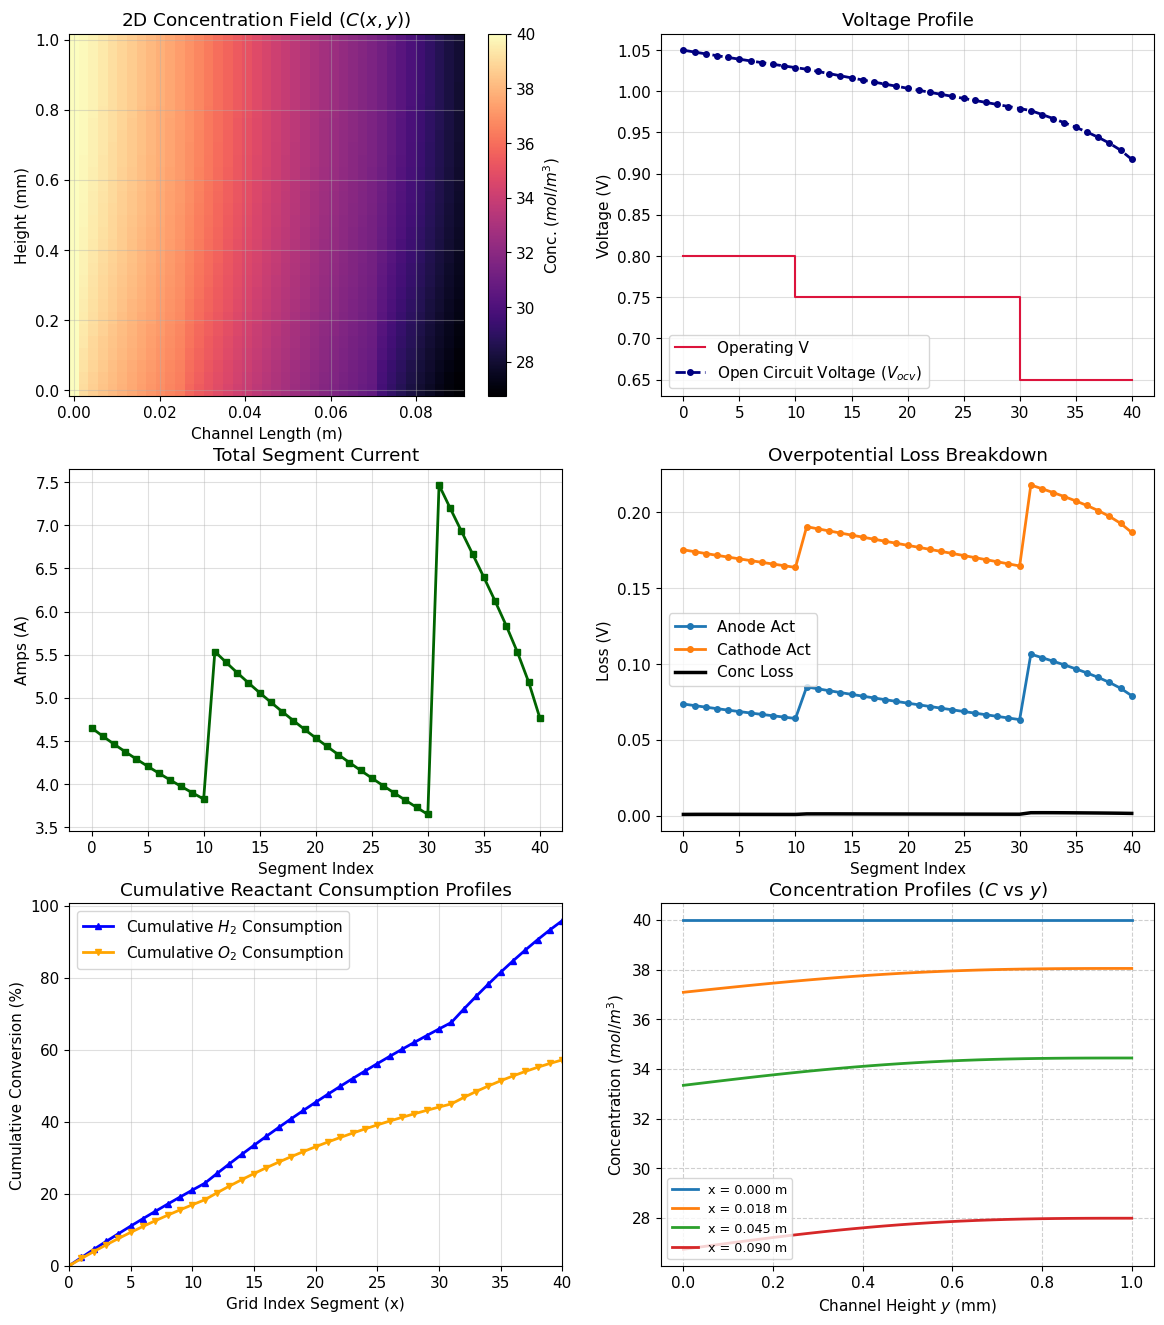

In [122]:
import numpy as np
import cantera as ct
from scipy.optimize import root
import matplotlib.pyplot as plt

# =============================================================================
# 1. FIXED PHYSICAL PARAMETERS & SYSTEM SPECIFICATIONS
# =============================================================================
P_kpa = 101.325        # kPa
P_pa = P_kpa * 1000.0  # Pa
F = 96485.0            # A-s/mol
R = 8.314              # J/mol-K
n = 2
Nseg = 40              # Total channel steps
A_act = 220.0          # Total active area (cm^2)
A_seg = A_act / Nseg   # Active area per slice (cm^2)

# 2D FEM TRANSPORT GEOMETRY SPECS
H_channel = 1e-3       # Channel height (m)
L_channel = 0.09       # Channel length (m)
Ny = 30                # Mesh nodes across height (y-direction)
dx = L_channel / Nseg
y_mesh = np.linspace(0, H_channel, Ny)
dy = y_mesh[1] - y_mesh[0]
D_diff = 2e-5          # Diffusivity (m^2/s)

# TARGET VOLTAGE PROFILE
V_cell_target = np.zeros(Nseg + 1)
for i in range(Nseg + 1):
    if i <= 10: V_cell_target[i] = 0.8
    elif i <= 20: V_cell_target[i] = 0.75
    elif i <= 30: V_cell_target[i] = 0.75
    else: V_cell_target[i] = 0.65

# INITIAL INLET FLOW RATES (mol/s)
n_dot_CO_0, n_dot_CO2_0 = 0.2e-4 * 15.0, 0.1e-4 * 15.0
n_dot_H2_0, n_dot_H2O_0, n_dot_O2_0 = 0.6e-4 * 15.0, 0.1e-4 * 15.0, 0.4e-4 * 15.0

T_cell_mesh = np.linspace(837.0, 837.0 + (40 * 1.15), Nseg + 1)
gas = ct.Solution('gri30.yaml')

def get_cantera_gibbs(species, Temp):
    gas.TPX = Temp, P_pa, {species: 1.0}
    return (gas.enthalpy_mole - Temp * gas.entropy_mole) / 1000.0

# FEM Matrices
M_mat, K_mat = np.zeros((Ny, Ny)), np.zeros((Ny, Ny))
u_max = 0.5 # Representative velocity
for i in range(Ny - 1):
    h_e = dy
    u_mid = u_max * (1 - (2 * (0.5*(y_mesh[i]+y_mesh[i+1])) / H_channel - 1)**2) + 1e-4
    Me = (u_mid * h_e / 6.0) * np.array([[2, 1], [1, 2]])
    Ke = (D_diff / h_e) * np.array([[1, -1], [-1, 1]])
    M_mat[i:i+2, i:i+2] += Me
    K_mat[i:i+2, i:i+2] += Ke
A_fem = M_mat / dx + K_mat

# =============================================================================
# 2. INTEGRATION LOOP
# =============================================================================
n_dot_H2, n_dot_CO = np.zeros(Nseg+2), np.zeros(Nseg+2)
n_dot_H2O, n_dot_CO2 = np.zeros(Nseg+2), np.zeros(Nseg+2)
n_dot_H2[0], n_dot_CO[0], n_dot_H2O[0], n_dot_CO2[0] = n_dot_H2_0, n_dot_CO_0, n_dot_H2_0, n_dot_CO2_0
fuel_tot = n_dot_H2 + n_dot_H2O + n_dot_CO2 + n_dot_CO
pO2 = np.zeros(Nseg+2); pO2[0] = 21.0
C_field = np.ones(Ny) * 40.0

I_total, V_ocv_out = [], []
V_act_an_out, V_act_ca_out, V_conc_out = [], [], []
C_2D_store = np.zeros((Nseg + 1, Ny))

for i in range(Nseg + 1):
    T_i = T_cell_mesh[i]
    C_bulk = max(1e-6, np.mean(C_field))
    C_2D_store[i, :] = C_field

    # Nernst Potentials
    g_H2, g_O2, g_H2O, g_CO, g_CO2 = [get_cantera_gibbs(s, T_i) for s in ['H2','O2','H2O','CO','CO2']]
    Vn = (-1.0*(g_H2O - g_H2 - 0.5*g_O2)/(n*F)) + (R*T_i)/(n*F)*np.log(((P_kpa*n_dot_H2[i]/fuel_tot[i])/P_kpa)*((pO2[i]/P_kpa)**0.5)/((P_kpa*n_dot_H2O[i]/fuel_tot[i])/P_kpa))
    VCn = (-1.0*(g_CO2 - g_CO - 0.5*g_O2)/(n*F)) + (R*T_i)/(n*F)*np.log(((P_kpa*n_dot_CO[i]/fuel_tot[i])/P_kpa)*((pO2[i]/P_kpa)**0.5)/((P_kpa*n_dot_CO2[i]/fuel_tot[i])/P_kpa))
    V_ocv = (Vn + VCn) / 2.0
    V_ocv_out.append(V_ocv)

    def residuals(guesses):
        j, j2, van, vca = guesses
        F_vec = np.zeros(Ny); F_vec[0] = -(j+j2)*10000.0 / (n * F)
        C_surf = np.linalg.solve(A_fem, M_mat.dot(C_field)/dx + F_vec)[0]
        v_conc = (R * T_i) / (n * F) * np.log(C_bulk / max(1e-6, C_surf))
        return [j - 0.3*(np.exp(0.5*n*F*van/R/T_i)-np.exp(-0.5*n*F*van/R/T_i)),
                (j+j2) - 0.075*(np.exp(0.5*n*F*vca/R/T_i)-np.exp(-0.5*n*F*vca/R/T_i)),
                j2 - 0.05*(np.exp(0.5*n*F*van/R/T_i)-np.exp(-0.5*n*F*van/R/T_i)),
                V_cell_target[i] - (V_ocv - (van + vca + v_conc))]

    sol = root(residuals, [0.3, 0.05, 0.05, 0.05], method='lm')
    j_v, j2_v, van, vca = sol.x
    I_total.append((j_v + j2_v) * A_seg)
    V_act_an_out.append(van); V_act_ca_out.append(vca)

    # Update FEM and Flow
    F_vec_final = np.zeros(Ny); F_vec_final[0] = -(j_v + j2_v)*10000.0 / (n * F)
    C_field = np.linalg.solve(A_fem, M_mat.dot(C_field)/dx + F_vec_final)
    V_conc_out.append((R * T_i)/(n * F)*np.log(C_bulk / max(1e-6, C_field[0])))

    n_dot_H2[i+1] = n_dot_H2[i] - (j_v * A_seg / (n*F))
    n_dot_CO[i+1] = n_dot_CO[i] - (j2_v * A_seg / (n*F))
    n_dot_H2O[i+1] = n_dot_H2O[i] + (j_v * A_seg / (n*F))
    n_dot_CO2[i+1] = n_dot_CO2[i] + (j2_v * A_seg / (n*F))
    fuel_tot[i+1] = n_dot_H2[i+1] + n_dot_H2O[i+1] + n_dot_CO2[i+1] + n_dot_CO[i+1]
    pO2[i+1] = pO2[i] - ((0.5*(j_v+j2_v)*A_seg/(n*F))/n_dot_O2_0)*pO2[i]

# Compute cumulative conversion for Plot 5
cum_consumption_H2 = (n_dot_H2[0] - n_dot_H2[:-1]) / n_dot_H2[0]
n_dot_O2_tracked = n_dot_O2_0 * (pO2[:-1] / 21.0)
cum_consumption_O2 = (n_dot_O2_0 - n_dot_O2_tracked) / n_dot_O2_0

# =============================================================================
# 4. ENHANCED PLOTTING SUITE
# =============================================================================
plt.figure(figsize=(14, 16))

# 1. 2D Concentration Contour Map
plt.subplot(3, 2, 1)
X_m, Y_m = np.meshgrid(np.linspace(0, L_channel, Nseg + 1), y_mesh * 1e3)
contour = plt.pcolormesh(X_m, Y_m, C_2D_store.T, cmap='magma', shading='auto')
plt.colorbar(contour, label="Conc. ($mol/m^3$)")
plt.title("2D Concentration Field ($C(x,y)$)")
plt.xlabel("Channel Length (m)")
plt.ylabel("Height (mm)")

# 2. Voltage and OCV Step Plot
plt.subplot(3, 2, 2)
x_grid = np.arange(Nseg + 1)
plt.step(x_grid, V_cell_target, color='crimson', label='Operating V')
plt.plot(x_grid, V_ocv_out, color='navy', linestyle='--', linewidth=2, marker='o', markersize=4, label=r'Open Circuit Voltage ($V_{ocv}$)')
plt.title("Voltage Profile")
plt.ylabel("Voltage (V)")
plt.legend()

# 3. Local Segment Current
plt.subplot(3, 2, 3)
plt.plot(x_grid, I_total, color='darkgreen', linewidth=2, marker='s', markersize=4, label='Total Segment Current ($I_{local}$)')
plt.title("Total Segment Current")
plt.xlabel("Segment Index")
plt.ylabel("Amps (A)")

# 4. Overpotential Breakdown
plt.subplot(3, 2, 4)
plt.plot(x_grid, V_act_an_out, label='Anode Act', linewidth=2,marker='o', markersize=4)
plt.plot(x_grid, V_act_ca_out, label='Cathode Act', linewidth=2,marker='o', markersize=4)
plt.plot(x_grid, V_conc_out, label='Conc Loss', color='black', linestyle='-', linewidth=2.5)
plt.title("Overpotential Loss Breakdown")
plt.xlabel("Segment Index")
plt.ylabel("Loss (V)")
plt.legend()

# 5. Cumulative Reactant Consumption
plt.subplot(3, 2, 5)
plt.plot(x_grid, cum_consumption_H2 * 100, color='blue', linewidth=2, marker='^', markersize=4, label=r'Cumulative $H_2$ Consumption')
plt.plot(x_grid, cum_consumption_O2 * 100, color='orange', linewidth=2, marker='v', markersize=4, label=r'Cumulative $O_2$ Consumption')
plt.title('Cumulative Reactant Consumption Profiles')
plt.xlabel('Grid Index Segment (x)')
plt.ylabel('Cumulative Conversion (%)')
plt.xlim(0, Nseg)
plt.ylim(bottom=0)
plt.legend(loc='best')

plt.subplot(3, 2, 6)
# Choose 4 indices to sample along the channel (0%, 20%, 50%, 99% of length)
x_samples = [0, int(Nseg * 0.2), int(Nseg * 0.5), Nseg]

for idx in x_samples:
    plt.plot(y_mesh * 1e3, C_2D_store[idx, :], linewidth=2, label=f"x = {idx * dx:.3f} m")

plt.title("Concentration Profiles ($C$ vs $y$)")
plt.xlabel("Channel Height $y$ (mm)")
plt.ylabel("Concentration ($mol/m^3$)")
plt.legend(fontsize='small')
plt.grid(True, linestyle='--', alpha=0.6)

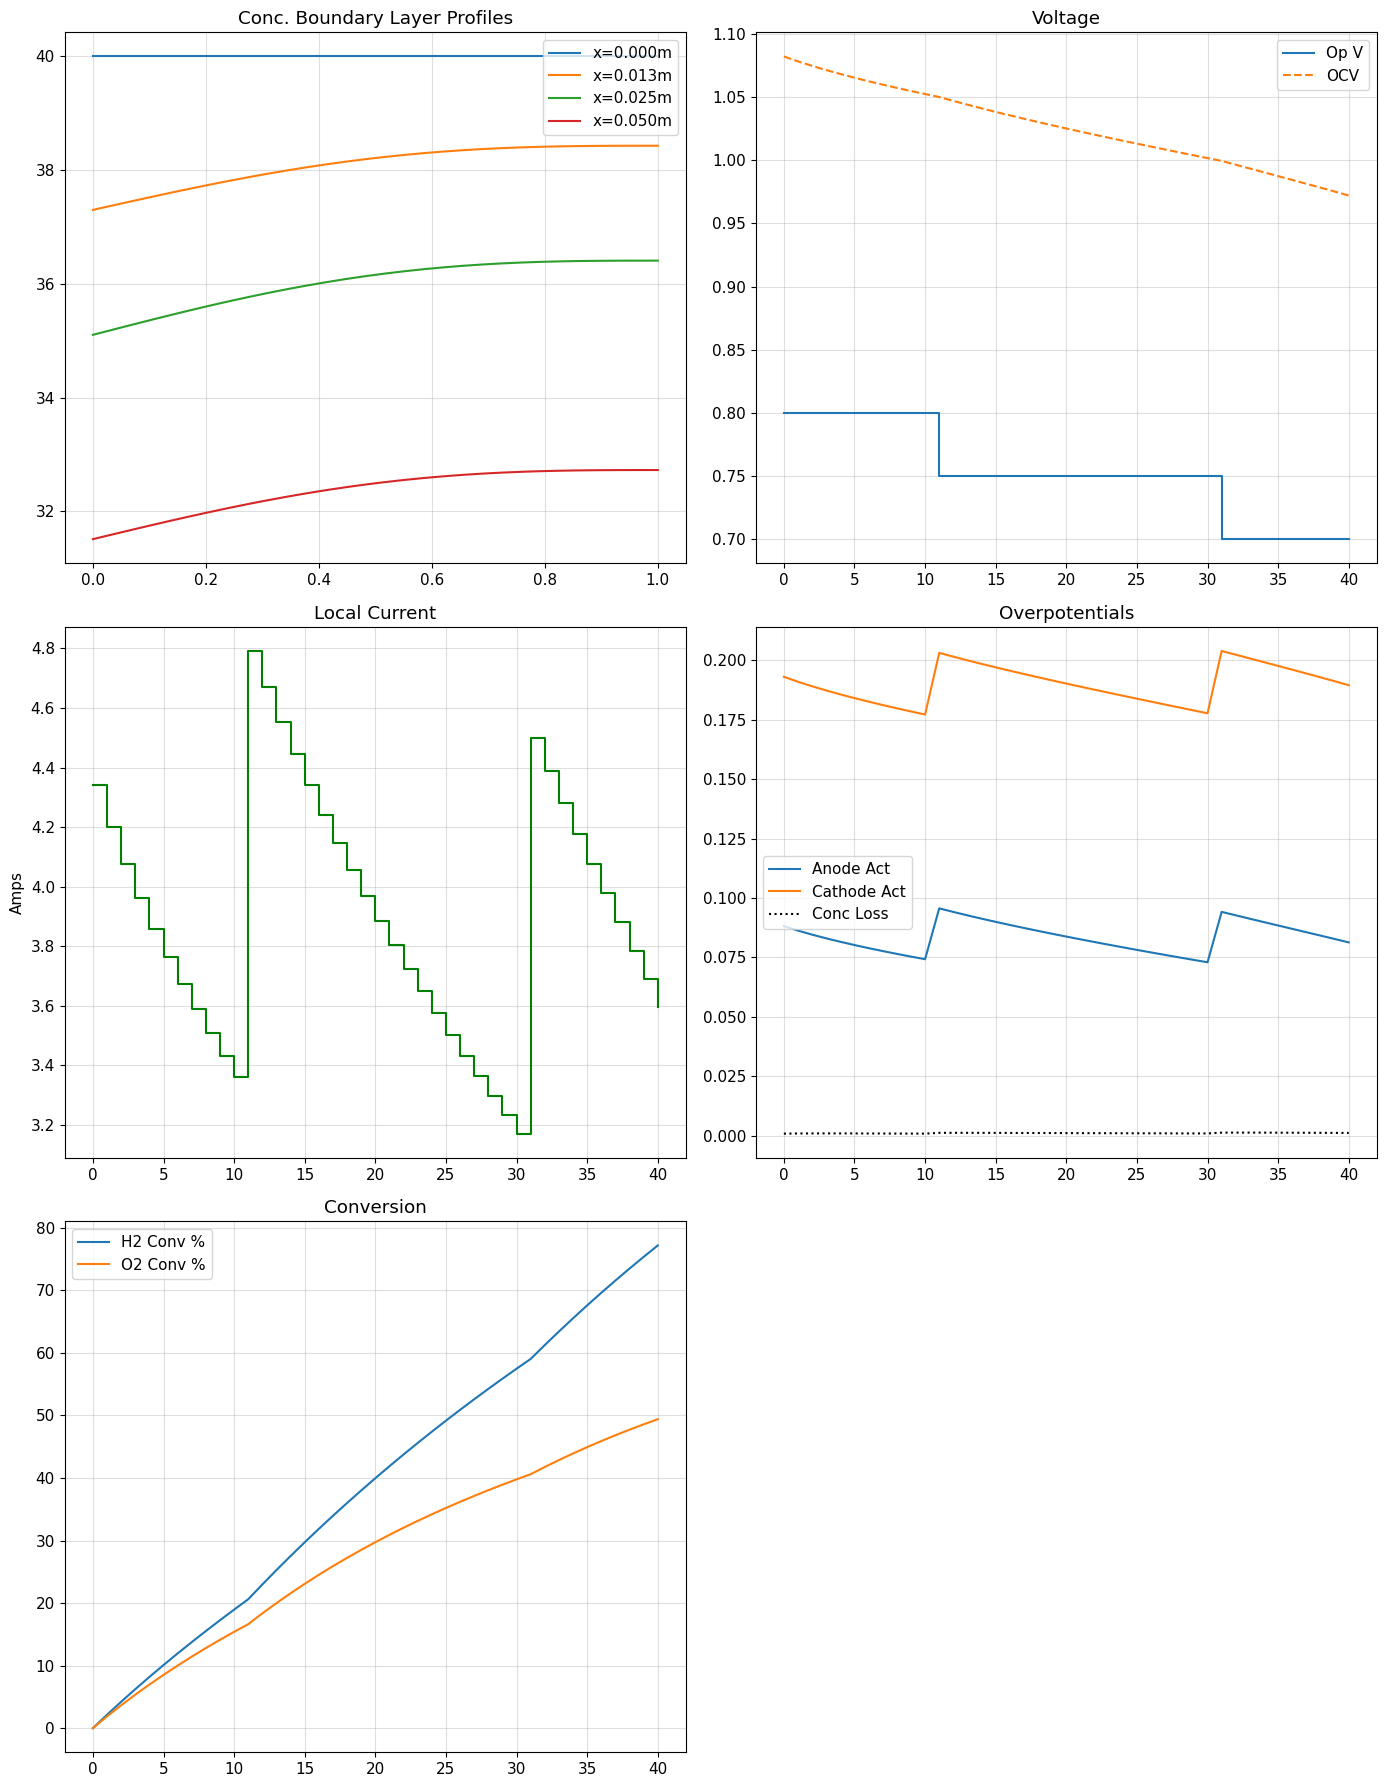

In [105]:
import numpy as np
import cantera as ct
from scipy.optimize import root
import matplotlib.pyplot as plt

# =============================================================================
# 1. PHYSICAL PARAMETERS & GEOMETRY
# =============================================================================
P_kpa, P_pa = 101.325, 101325.0
F, R, n = 96485.0, 8.314, 2
Nseg = 40
A_act = 160.0
A_seg = A_act / Nseg

# 2D FEM SPECS
H_channel, L_channel = 1e-3, 0.05
Ny = 30
dx = L_channel / Nseg
dy = H_channel / (Ny - 1)
y_mesh = np.linspace(0, H_channel, Ny)
D_diff = 2e-5

# TARGET VOLTAGE
V_cell_target = np.array([0.8]*11 + [0.75]*10 + [0.75]*10 + [0.7]*10)

# INLET FLOWS (mol/s)
n_dot_CO_0, n_dot_CO2_0 = 0.2e-4 * 15.0, 0.1e-4 * 15.0
n_dot_H2_0, n_dot_H2O_0, n_dot_O2_0 = 0.6e-4 * 15.0, 0.1e-4 * 15.0, 0.4e-4 * 15.0

T_cell_mesh = np.linspace(837.0, 837.0 + (40 * 1.15), Nseg + 1)
gas = ct.Solution('gri30.yaml')

def get_cantera_gibbs(species, Temp):
    gas.TPX = Temp, P_pa, {species: 1.0}
    return (gas.enthalpy_mole - Temp * gas.entropy_mole) / 1000.0

# Build FEM Matrices
M_mat, K_mat = np.zeros((Ny, Ny)), np.zeros((Ny, Ny))
u_max = 0.5
for i in range(Ny - 1):
    u_mid = u_max * (1 - (2 * (0.5*(y_mesh[i]+y_mesh[i+1])) / H_channel - 1)**2) + 1e-4
    Me = (u_mid * dy / 6.0) * np.array([[2, 1], [1, 2]])
    Ke = (D_diff / dy) * np.array([[1, -1], [-1, 1]])
    M_mat[i:i+2, i:i+2] += Me
    K_mat[i:i+2, i:i+2] += Ke
A_fem = M_mat / dx + K_mat

# =============================================================================
# 2. INTEGRATION LOOP
# =============================================================================
n_dot_H2, n_dot_CO = np.zeros(Nseg+2), np.zeros(Nseg+2)
n_dot_H2O, n_dot_CO2 = np.zeros(Nseg+2), np.zeros(Nseg+2)
n_dot_H2[0], n_dot_CO[0], n_dot_H2O[0], n_dot_CO2[0] = n_dot_H2_0, n_dot_CO_0, n_dot_H2O_0, n_dot_CO2_0
fuel_tot = n_dot_H2 + n_dot_H2O + n_dot_CO2 + n_dot_CO
pO2 = np.zeros(Nseg+2); pO2[0] = 21.0
C_field = np.ones(Ny) * 40.0
C_2D_store = np.zeros((Nseg + 1, Ny))

I_total, V_ocv_out = [], []
V_act_an_out, V_act_ca_out, V_conc_out = [], [], []

for i in range(Nseg + 1):
    T_i = T_cell_mesh[i]
    C_bulk = max(1e-6, np.mean(C_field))
    C_2D_store[i, :] = C_field

    g_H2, g_O2, g_H2O, g_CO, g_CO2 = [get_cantera_gibbs(s, T_i) for s in ['H2','O2','H2O','CO','CO2']]
    Vn = (-1.0*(g_H2O - g_H2 - 0.5*g_O2)/(n*F)) + (R*T_i)/(n*F)*np.log(((P_kpa*n_dot_H2[i]/max(1e-9, fuel_tot[i]))/P_kpa)*((pO2[i]/P_kpa)**0.5)/((P_kpa*n_dot_H2O[i]/max(1e-9, fuel_tot[i]))/P_kpa))
    VCn = (-1.0*(g_CO2 - g_CO - 0.5*g_O2)/(n*F)) + (R*T_i)/(n*F)*np.log(((P_kpa*n_dot_CO[i]/max(1e-9, fuel_tot[i]))/P_kpa)*((pO2[i]/P_kpa)**0.5)/((P_kpa*n_dot_CO2[i]/max(1e-9, fuel_tot[i]))/P_kpa))
    V_ocv = (Vn + VCn) / 2.0
    V_ocv_out.append(V_ocv)

    def residuals(guesses):
        j, j2, van, vca = guesses
        F_vec = np.zeros(Ny); F_vec[0] = -(j+j2)*10000.0 / (n * F)
        C_surf = np.linalg.solve(A_fem, M_mat.dot(C_field)/dx + F_vec)[0]
        v_conc = (R * T_i) / (n * F) * np.log(C_bulk / max(1e-6, C_surf))
        return [j - 0.3*(np.exp(0.5*n*F*van/R/T_i)-np.exp(-0.5*n*F*van/R/T_i)),
                (j+j2) - 0.075*(np.exp(0.5*n*F*vca/R/T_i)-np.exp(-0.5*n*F*vca/R/T_i)),
                j2 - 0.05*(np.exp(0.5*n*F*van/R/T_i)-np.exp(-0.5*n*F*van/R/T_i)),
                V_cell_target[i] - (V_ocv - (van + vca + v_conc))]

    sol = root(residuals, [0.3, 0.05, 0.05, 0.05], method='lm')
    j_v, j2_v, van, vca = sol.x
    I_total.append((j_v + j2_v) * A_seg)
    V_act_an_out.append(van); V_act_ca_out.append(vca)

    F_vec_final = np.zeros(Ny); F_vec_final[0] = -(j_v + j2_v)*10000.0 / (n * F)
    C_field = np.linalg.solve(A_fem, M_mat.dot(C_field)/dx + F_vec_final)
    V_conc_out.append((R * T_i)/(n * F)*np.log(C_bulk / max(1e-6, C_field[0])))

    n_dot_H2[i+1] = n_dot_H2[i] - (j_v * A_seg / (n*F))
    n_dot_CO[i+1] = n_dot_CO[i] - (j2_v * A_seg / (n*F))
    n_dot_H2O[i+1] = n_dot_H2O[i] + (j_v * A_seg / (n*F))
    n_dot_CO2[i+1] = n_dot_CO2[i] + (j2_v * A_seg / (n*F))
    fuel_tot[i+1] = n_dot_H2[i+1] + n_dot_H2O[i+1] + n_dot_CO2[i+1] + n_dot_CO[i+1]
    pO2[i+1] = pO2[i] - ((0.5*(j_v+j2_v)*A_seg/(n*F))/n_dot_O2_0)*pO2[i]

# =============================================================================
# 3. PLOTTING SUITE
# =============================================================================
x_plot = range(Nseg + 1)
plt.figure(figsize=(14, 18))
plt.subplot(3, 2, 1)
for idx in [0, 10, 20, Nseg]:
    plt.plot(y_mesh * 1e3, C_2D_store[idx, :], label=f"x={idx*dx:.3f}m")
plt.title("Conc. Boundary Layer Profiles"); plt.legend(); plt.grid(True)
plt.subplot(3, 2, 2)
plt.step(x_plot, V_cell_target, where='post', label='Op V'); plt.plot(V_ocv_out, '--', label='OCV'); plt.legend(); plt.title("Voltage")
plt.subplot(3, 2, 3)
plt.step(x_plot, I_total, where='post', color='green'); plt.title("Local Current"); plt.ylabel("Amps")
plt.subplot(3, 2, 4)
plt.plot(V_act_an_out, label='Anode Act'); plt.plot(V_act_ca_out, label='Cathode Act'); plt.plot(V_conc_out, 'k:', label='Conc Loss'); plt.legend(); plt.title("Overpotentials")
plt.subplot(3, 2, 5)
plt.plot(x_plot, (n_dot_H2[0]-n_dot_H2[:Nseg+1])/n_dot_H2[0]*100, label='H2 Conv %')
plt.plot(x_plot, (21.0-pO2[:Nseg+1])/21.0*100, label='O2 Conv %')
plt.legend(); plt.title("Conversion")
plt.tight_layout(); plt.show()